# MariaCiko_Unit2_BIOL672

MacOS Sonoma 14.6.1

Data files: sf_military.csv

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    # GridSearchCV,
    # RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
# from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# To stop getting warnings
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)


## PART 1

In [30]:
df = pd.read_csv('sf_military.csv')
df.head(3) # 1250 rows × 11 columns

,Book_Title,Original_Book_Title,Author_Name,Edition_Language,Rating_score,Rating_votes,Review_number,Book_Description,Year_published,Genres,url
0,Old Man's War,Old Man's War,John Scalzi,English,4.21,168390,9719,John Perry did two things on his 75th birthday...,2005,"{'Science Fiction': 5012, 'Fiction': 1428, 'Sp...",https://www.goodreads.com/book/show/36510196-o...
1,On Basilisk Station,On Basilisk Station,David Weber,English,4.13,42410,2016,Honor Harrington in trouble: Having made him l...,1992,"{'Science Fiction': 1619, 'Space (Space Opera)...",https://www.goodreads.com/book/show/35921.On_B...
2,Dauntless,"Dauntless (The Lost Fleet, #1)",Jack Campbell,English,3.96,27813,1584,The Alliance has been fighting the Syndics for...,2006,"{'Science Fiction': 1098, 'Space (Space Opera)...",https://www.goodreads.com/book/show/112292.Dau...


In [31]:
print((df != '?').all()) # check for missing values; True means no missing values
# print((df == '?').sum())

Book_Title             True
Original_Book_Title    True
Author_Name            True
Edition_Language       True
Rating_score           True
Rating_votes           True
Review_number          True
Book_Description       True
Year_published         True
Genres                 True
url                    True
dtype: bool


### Check for class imbalance
Let's consider two classes: ratings >4.1 and those <4.1

In [32]:
# Create binary classes
df['Rating_class'] = (df['Rating_score'] > 4.1).astype(int) # 1 if >4.1, 0 otherwise
df['Rating_class'].value_counts(normalize=True)

Rating_class
0    0.568
1    0.432
Name: proportion, dtype: float64

### Split data into training and test sets to predict if Rating_score will be greater/lower than 4.1

In [33]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)
train_df.head() # 1000 rows × 11 columns

,Book_Title,Original_Book_Title,Author_Name,Edition_Language,Rating_score,Rating_votes,Review_number,Book_Description,Year_published,Genres,url,Rating_class
1194,Dawn,銀河英雄伝説 1 黎明篇,Yoshiki Tanaka,English,4.05,1190,140,"“The Golden Brat” Reinhard von Lohengramm, a m...",1982,"{'Science Fiction': 91, 'Fiction': 31, 'Space ...",https://www.goodreads.com/book/show/25986983-dawn,0
911,Foreign Legions,Foreign Legions,David Drake,English,3.92,630,16,A collection of novellas by some of today's mo...,2001,"{'Science Fiction': 22, 'Fiction': 10, 'War (M...",https://www.goodreads.com/book/show/57375.Fore...,0
422,The Clone Empire,\r\n 0441019587\r\n ...,Steven L. Kent,English,3.85,680,20,"After a blistering defeat by alien forces, clo...",2010,"{'Science Fiction': 36, 'War (Military Fiction...",https://www.goodreads.com/book/show/8231029-th...,0
670,King David's Spaceship,King David's Spaceship,Jerry Pournelle,English,3.84,1963,53,"In the time of John Christian Falkenberg, the ...",1973,"{'Science Fiction': 26, 'Fiction': 24, 'Space ...",https://www.goodreads.com/book/show/1329611.Ki...,0
931,Space Wolf,Space Wolf,William King,English,4.09,1723,78,After being revived from a savage death on the...,1999,"{'Science Fiction': 61, '40k': 22, 'Fiction': ...",https://www.goodreads.com/book/show/691582.Spa...,0


In [34]:
# Separate X and y
X_train = train_df.drop(columns=['Rating_class'])
y_train = train_df['Rating_class']

X_test = test_df.drop(columns=['Rating_class'])
y_test = test_df['Rating_class']

In [35]:
# Define types of features
numeric_features = ['Rating_score','Rating_votes', 'Review_number', 'Year_published']
categorical_features = ['Book_Title', 'Original_Book_Title', 'Author_Name', 'Edition_Language', 'Book_Description', 'Genres']
drop_features = 'url'

### Define transformers to make a pipeline to streamline the learning process

In [36]:
numeric_transformer = make_pipeline(StandardScaler())


categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    ("drop", drop_features)
)

In [37]:
print(df.columns)

Index(['Book_Title', 'Original_Book_Title', 'Author_Name', 'Edition_Language',
       'Rating_score', 'Rating_votes', 'Review_number', 'Book_Description',
       'Year_published', 'Genres', 'url', 'Rating_class'],
      dtype='object')


### Models to train

In [38]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}

print(models)
# print(models.keys())
# print(models.values())
print(models.items())

{'KNN': KNeighborsClassifier(n_neighbors=3), 'Naive Bayes': GaussianNB(), 'LDA': LinearDiscriminantAnalysis(), 'QDA': QuadraticDiscriminantAnalysis()}
dict_items([('KNN', KNeighborsClassifier(n_neighbors=3)), ('Naive Bayes', GaussianNB()), ('LDA', LinearDiscriminantAnalysis()), ('QDA', QuadraticDiscriminantAnalysis())])


In [39]:
# Evaluate models
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores['test_score'].mean()

# pd.DataFrame(scores)

# Print results
print("Cross-Validation Results:")
for name, score in results.items():
    print(f"{name}: {score:.3f}")

/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mariaciko/anaconda3/envs/stat/lib/pyth

Cross-Validation Results:
KNN: 0.931
Naive Bayes: 0.586
LDA: nan
QDA: 0.770


Based on the cv results, kNN classifier with 3 neighbors had the highest accuracy of 0.931 and the least accurate was Naive Bayes at 0.586. With 10 neighbors, kNN was at 0.943. An interesting note is that increasing the number of neighbors with kNN led to a higher accuracy score, which doesn't make sense, because this is an algorithm that looks for the nearest neighbors based on Euclidean distance. Therefore, the more neighbors we specify, the range of relevant data points increases, at the cost of compromising accuracy. So the fewer neighbors we have (lower k) leads to overfitting which shows up as high accuracy. For whatever reason, this is not what we see.

### Fit the models and visualize results

In the confusion matrices, the color gradient indicates the number of cases, with darker shades corresponding to fewer cases and lighter ones being more cases. 

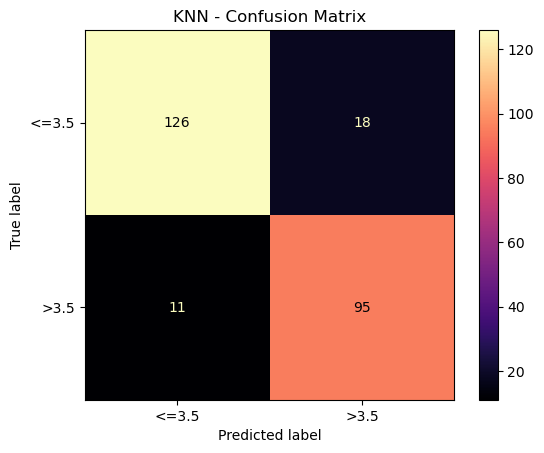

KNN - Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       144
           1       0.84      0.90      0.87       106

    accuracy                           0.88       250
   macro avg       0.88      0.89      0.88       250
weighted avg       0.89      0.88      0.88       250



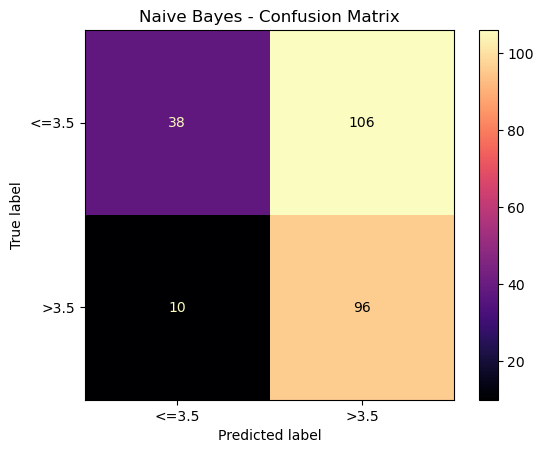

Naive Bayes - Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.26      0.40       144
           1       0.48      0.91      0.62       106

    accuracy                           0.54       250
   macro avg       0.63      0.58      0.51       250
weighted avg       0.66      0.54      0.49       250



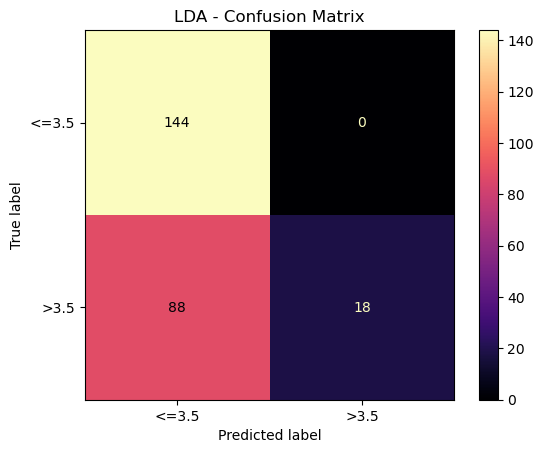

LDA - Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77       144
           1       1.00      0.17      0.29       106

    accuracy                           0.65       250
   macro avg       0.81      0.58      0.53       250
weighted avg       0.78      0.65      0.56       250



/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


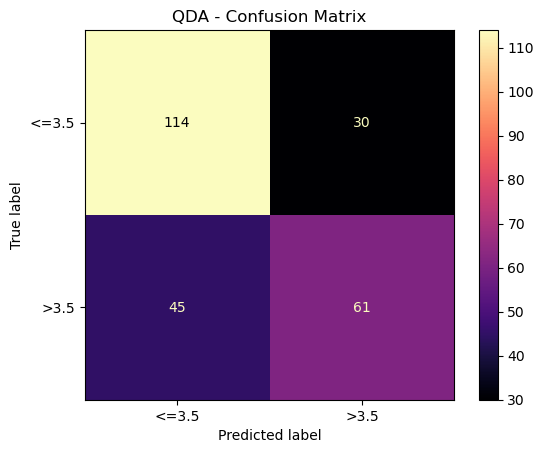

QDA - Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       144
           1       0.67      0.58      0.62       106

    accuracy                           0.70       250
   macro avg       0.69      0.68      0.69       250
weighted avg       0.70      0.70      0.70       250



In [40]:
# Visualizations
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=3.5', '>3.5'])
    disp.plot(cmap='magma')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    print(f"{name} - Classification Report:")
    print(classification_report(y_test, y_pred))

### Scatterplot for clustering

/var/folders/k6/sj6r7r3x45l7x9bbvhm3n88r0000gn/T/ipykernel_36866/4177583869.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[numeric_features[0]], X_test[numeric_features[1]], cmap='Blues', marker='+', linewidth=1)


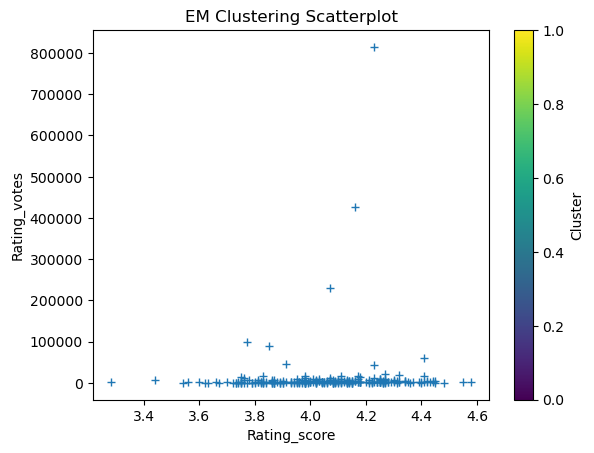

In [41]:
plt.scatter(X_test[numeric_features[0]], X_test[numeric_features[1]], cmap='Blues', marker='+', linewidth=1)
plt.title("EM Clustering Scatterplot")
plt.xlabel(numeric_features[0])
plt.ylabel(numeric_features[1])
plt.colorbar(label='Cluster')
plt.show()

## PART 2

Support vector machine classifier


Kernel: linear
Accuracy: 0.972
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       144
           1       0.97      0.96      0.97       106

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250



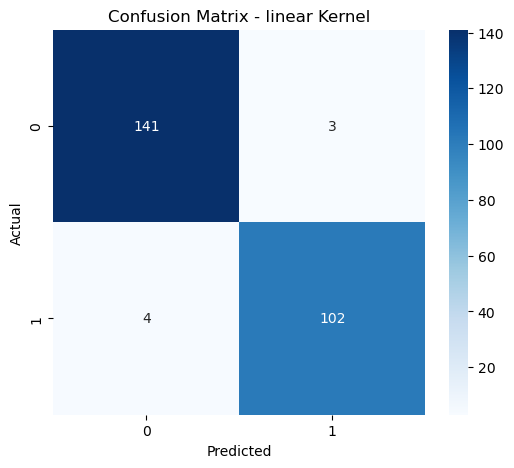


Kernel: poly
Accuracy: 0.584
Classification Report:
              precision    recall  f1-score   support

           0       0.58      1.00      0.73       144
           1       1.00      0.02      0.04       106

    accuracy                           0.58       250
   macro avg       0.79      0.51      0.39       250
weighted avg       0.76      0.58      0.44       250



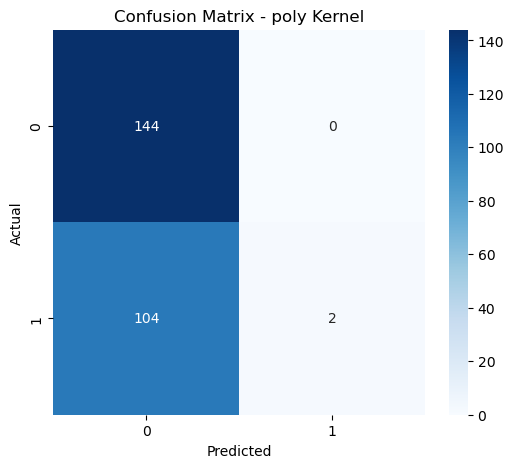


Kernel: rbf
Accuracy: 0.960
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       144
           1       0.97      0.93      0.95       106

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



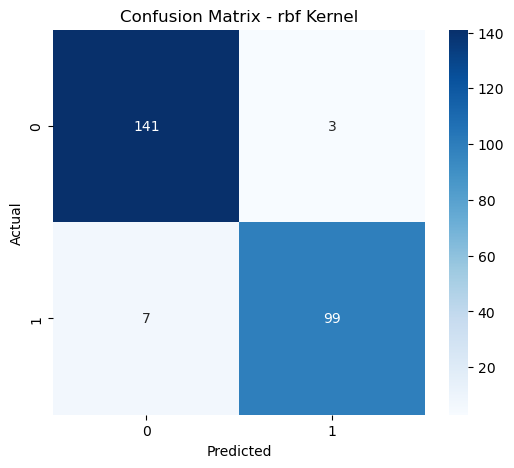

In [42]:
# Define kernel types
kernels = ['linear', 'poly', 'rbf']
results = {}

for kernel in kernels:
    # Create SVM model with specific kernel
    svm = SVC(kernel=kernel, gamma=0.01, random_state=42)
    
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', svm)
    ])
    
    # Cross-validation with 5 folds
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring='accuracy', return_train_score=False)
    mean_validation_score = np.mean(scores['test_score'])
    results[kernel] = mean_validation_score
    
    # Fit and predict on the training set for confusion matrix
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Confusion matrix
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.title(f'Confusion Matrix - {kernel} Kernel')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Cross-validation results

In [43]:
print("\nMean Validation Scores:\n-----------------------")
for kernel, score in results.items():
    print(f"{kernel.capitalize()} Kernel: {score:.3f}")


Mean Validation Scores:
-----------------------
Linear Kernel: 0.983
Poly Kernel: 0.567
Rbf Kernel: 0.979


INTERPRETATION: 

The linear kernel of the svm classifier had the highest validation score at 0.983, followed closely by the rbf, and finally the polynomial which scored the worst at 0.567.

### Scatterplot for Decision Boundary Visualization

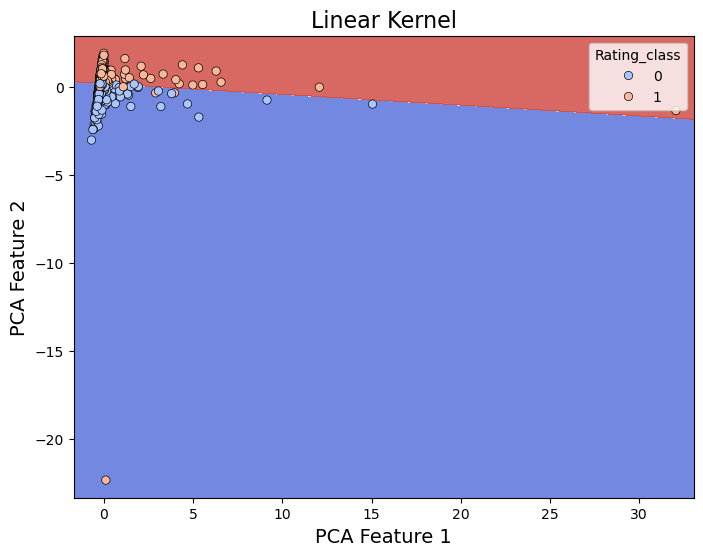

Linear Kernel Decision Boundary Fit: 0.960


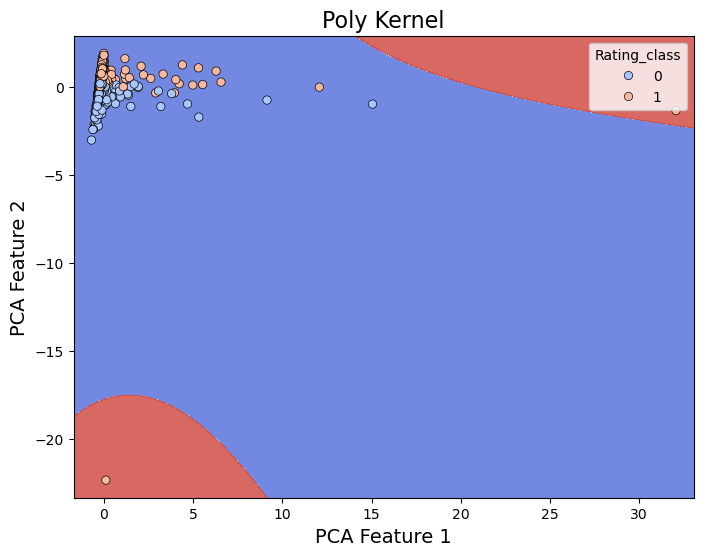

Poly Kernel Decision Boundary Fit: 0.568


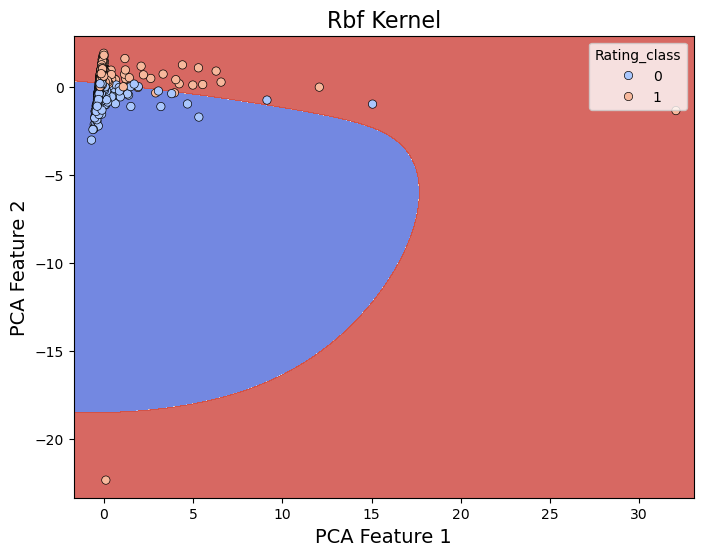

Rbf Kernel Decision Boundary Fit: 0.959


In [44]:
# Reduce features to 2D for visualization using PCA
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(preprocessor.fit_transform(X_train))

for kernel in kernels:
    # Create SVM model with specific kernel
    svm = SVC(kernel=kernel, gamma=0.01, random_state=42)
    svm.fit(X_train_2D, y_train)

    # Generate meshgrid for decision boundary
    x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
    y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                        np.arange(y_min, y_max, 0.01))

    # Predict over the meshgrid
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    sns.scatterplot(x=X_train_2D[:, 0], y=X_train_2D[:, 1], hue=y_train, palette='coolwarm', edgecolor='k')
    plt.title(f'{kernel.capitalize()} Kernel', fontsize=16)
    plt.xlabel('PCA Feature 1', fontsize=14)
    plt.ylabel('PCA Feature 2', fontsize=14)
    plt.show()

    # Score the fit of the decision boundary
    db_fit = svm.score(X_train_2D, y_train)
    print(f"{kernel.capitalize()} Kernel Decision Boundary Fit: {db_fit:.3f}")



As seen by the decision boundary graphs, the polynomial kernel does the poorest job at separating the classes. The rbf kernel performs a lot better at a 0.959 fit, and finally the linear excels with a 0.960 fit. However, such high scores are prone to overfitting, meaning the model is not learning and will not generalize well to new data.

### Neural Networks

In [45]:
X_train_transformed = preprocessor.fit_transform(X_train)
print(X_train_transformed.shape)

(1000, 4208)


In [46]:
# Build a simple neural network
simple_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)),  # Input layer
    Dense(32, activation='relu'),  # Hidden layer
    Dense(len(np.unique(y_train)), activation='softmax')  # Output layer
])

# Compile the model
simple_nn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Train the model
history_simple = simple_nn.fit(preprocessor.fit_transform(X_train), y_train, 
                               epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate on the test set
y_pred_nn = np.argmax(simple_nn.predict(preprocessor.transform(X_test)), axis=1)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print(f"Simple Neural Network Accuracy: {accuracy_nn:.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_nn))

/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Simple Neural Network Accuracy: 0.912
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       144
           1       0.88      0.92      0.90       106

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Layers: 1
Deep NN Accuracy: 0.932


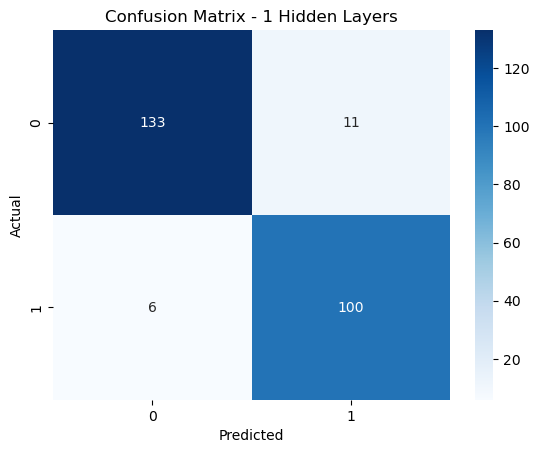

/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Layers: 2
Deep NN Accuracy: 0.932


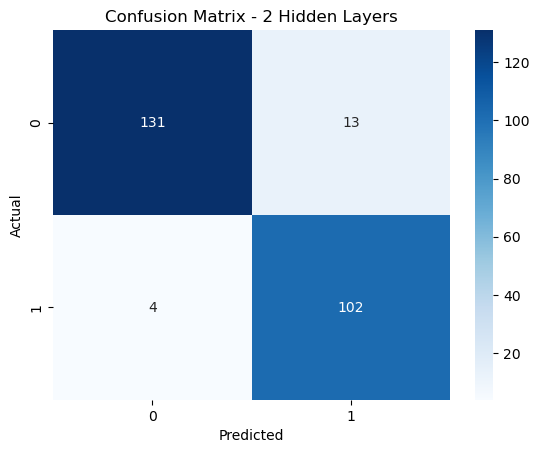

/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Layers: 3
Deep NN Accuracy: 0.944


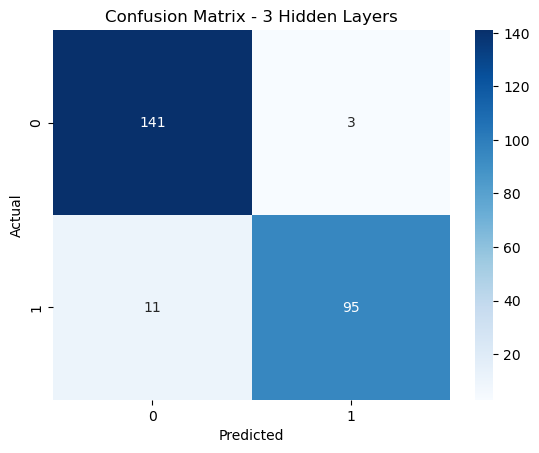

/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Layers: 4
Deep NN Accuracy: 0.968


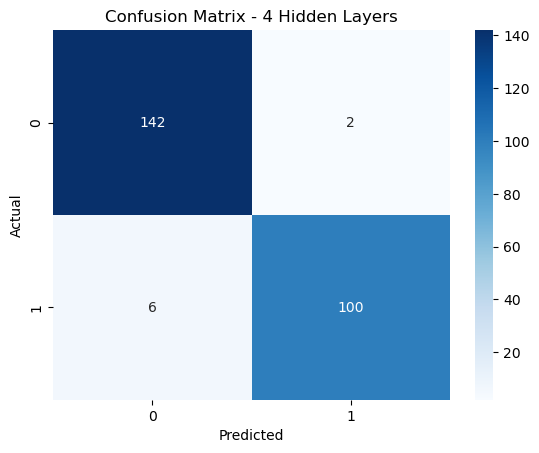

/Users/mariaciko/anaconda3/envs/stat/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Layers: 5
Deep NN Accuracy: 0.932


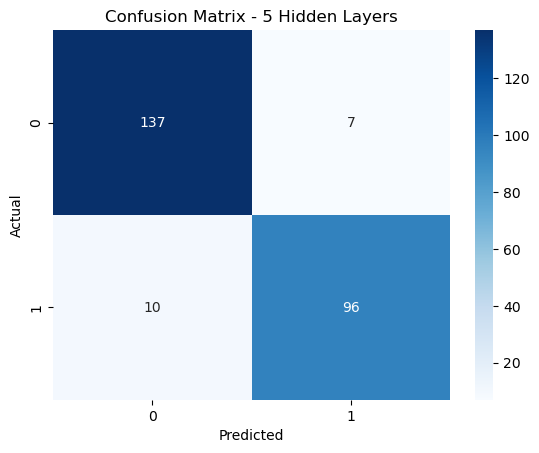

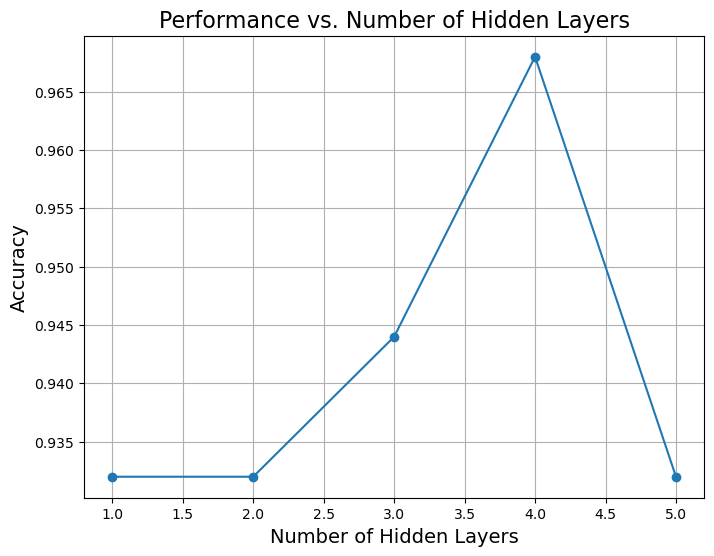

In [47]:
# Build deep learning models with varying layers
def build_deep_nn(num_layers):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X_train_transformed.shape[1],)))  # Input layer
    for _ in range(num_layers):  # Add hidden layers
        model.add(Dense(128, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))  # Output layer
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train and evaluate models with different depths
layer_performance = []
for layers in range(1, 6):  # Try 1 to 5 hidden layers
    deep_nn = build_deep_nn(layers)
    history = deep_nn.fit(preprocessor.fit_transform(X_train), y_train, 
                          epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    y_pred_deep = np.argmax(deep_nn.predict(preprocessor.transform(X_test)), axis=1)
    test_accuracy = accuracy_score(y_test, y_pred_deep)
    layer_performance.append((layers, test_accuracy))

    # Plot confusion matrix
    print(f"\nLayers: {layers}")
    print(f"Deep NN Accuracy: {test_accuracy:.3f}")
    cm = confusion_matrix(y_test, y_pred_deep)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {layers} Hidden Layers')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot accuracy as a function of number of layers
layers, accuracies = zip(*layer_performance)
plt.figure(figsize=(8, 6))
plt.plot(layers, accuracies, marker='o')
plt.title('Performance vs. Number of Hidden Layers', fontsize=16)
plt.xlabel('Number of Hidden Layers', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid()
plt.show()


### Random Forest Classifier

Random Forest Accuracy: 0.992
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       144
           1       0.98      1.00      0.99       106

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



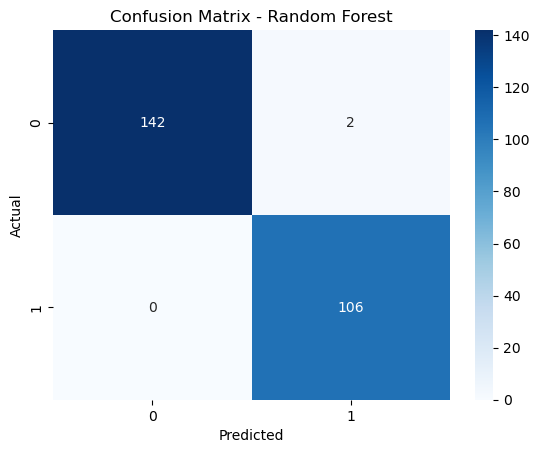

In [48]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_model.fit(preprocessor.fit_transform(X_train), y_train)
rf_predictions = rf_model.predict(preprocessor.transform(X_test))

# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

AdaBoost Accuracy: 1.000
Classification Report for AdaBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       144
           1       1.00      1.00      1.00       106

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



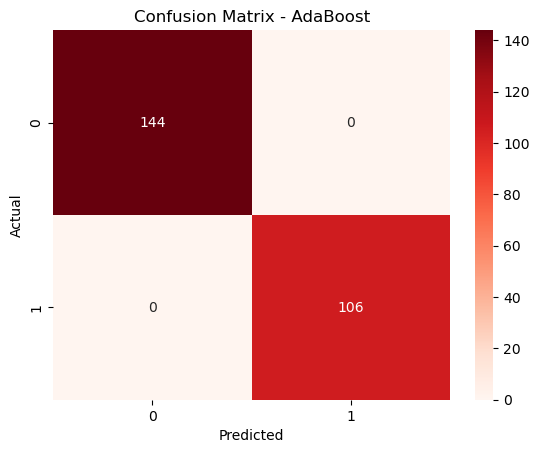

In [49]:
# AdaBoost Classifier
ab_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ab_model.fit(preprocessor.fit_transform(X_train), y_train)
ab_predictions = ab_model.predict(preprocessor.transform(X_test))

# Evaluate AdaBoost
ab_accuracy = accuracy_score(y_test, ab_predictions)
print(f"AdaBoost Accuracy: {ab_accuracy:.3f}")
print("Classification Report for AdaBoost:")
print(classification_report(y_test, ab_predictions))

# Confusion Matrix for AdaBoost
cm_ab = confusion_matrix(y_test, ab_predictions)
sns.heatmap(cm_ab, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


           Model  Accuracy
0  Random Forest     0.992
1       AdaBoost     1.000


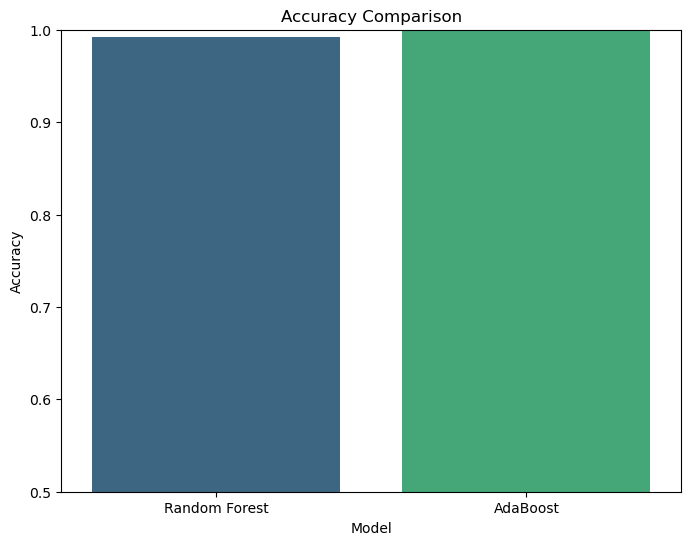

In [50]:
# Summary Comparison
results = {
    "Model": ["Random Forest", "AdaBoost"],
    "Accuracy": [rf_accuracy, ab_accuracy],
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

# Visualization
plt.figure(figsize=(8, 6))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette="viridis")
plt.title("Accuracy Comparison")
plt.ylim(0.5, 1.0)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()


Both classifiers perform relatively the same, with AdaBoost reaching 1.0 accuracy, as it assigns higher weights to misclassified examples in every iteration. The random forest uses bootstrap sampling from multiple decision trees (a forest is made up of trees) and averages results. Both are great but with greatness comes a price ( overfitting!!!).